## This Jupyter Notebook aims to understand ERT using pyGIMLi.

### Objectives:
#### 1. Create the main subsurface geometry (domain).
#### 2. Generate random geological features with high or low resistivity.
#### 3. Generate synthetic ERT data using electrodes in pyGIMLi.
#### 4. Save the synthetic data.
#### 5. Use the ERT Manager to invert the data and interpret the subsurface features.
#### 6. Improve the inversion results by incorporating existing geological knowledge of the subsurface.

In [1]:
import pygimli as pg    #import pygimli module
import pygimli.meshtools as mt   #import meshtools to creat geometry

(<Axes: xlabel='$x$ in m'>, None)

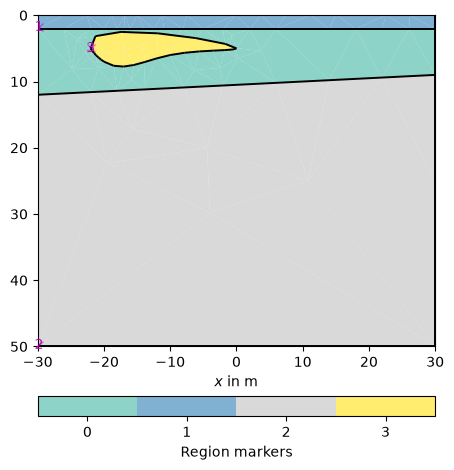

In [2]:
left = 30   #coordinate of left extent of model (in m)
right = 30  #coordinate of right extent of model (in m)
depth = 50  #depth of the model (in m)

# create the model extent
domain = mt.createWorld(start = [-left, 0], 
                        end = [right, -depth], 
                       layers = [-2])

# creat a shape which will have very high resistivity
blob = mt.createPolygon([[-22, -5], [-20, -7], [-10, -6], [0, -5]], 
                       isClosed=True, 
                       addNodes=5,
                       interpolate= 'spline', 
                       marker = 3)
# add an inclined layer
line = mt.createLine(start = [-left, -12], end = [right, -9])
geometry = blob + domain +line
pg.show(geometry)

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x735ba0d08c50>)

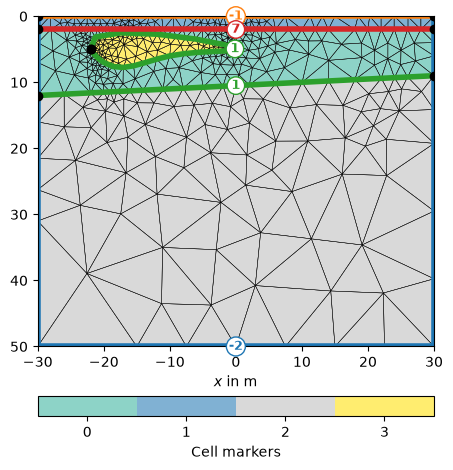

In [3]:
#create mesh
mesh = mt.createMesh(geometry, quality = 33.5)
pg.show(mesh, markers = True, showMesh = True)

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x735ba3144ed0>)

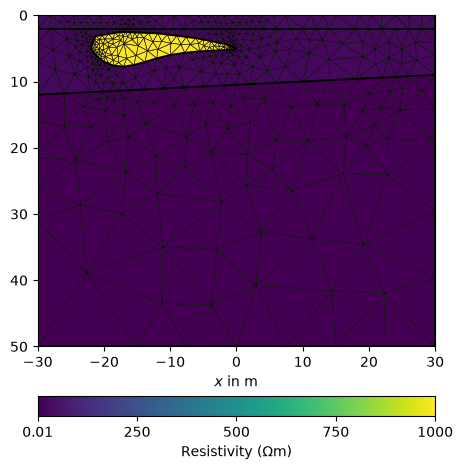

In [4]:
# assign resistivity to each layer defined by the marker number
# the list has two values
# first one is the marker number and the 2nd one is the corresponding resistivity value
rhomap = [[0, 20],
        [1, 30], 
        [2, 0.01], 
        [3, 1000]
       ]
pg.show(mesh, data=rhomap, showMesh=True, label = pg.unit('res'), logscale = True)

In [5]:
# import ert module to create synthetic data
from pygimli.physics import ert
import numpy as np

In [6]:
# put the electrodes and use any scheme of ERT array 
# dd is dipole-dipole
# check with other scheme, such as, 'wa' > Wenner-Alfa
scheme = ert.createData(elecs=np.linspace(-25, 25, 21), 
                       schemeName='dd') 

29/09/26 - 22:49:57 - pyGIMLi - INFO - Cache /home/jyotirmp/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 4): /home/jyotirmp/.cache/pygimli/17385885611949548145


In [7]:
#simulate synthetic data and save the data
#must introduce error in the data
synthetic_data = ert.simulate(mesh, scheme=scheme, res = rhomap, noiseLevel=1, noiseAbs=1e-6)
synthetic_data.remove(synthetic_data['rhoa'] < 0)
synthetic_data.save('syn_data2.dat')

29/09/26 - 22:49:57 - pyGIMLi - INFO - Data error estimate (min:max)  0.010000649509113656 : 0.018472090585589553


ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 free-electrodes
rMin = 1.25, rMax = 100
NGauLeg + NGauLag for inverse Fouriertransformation: 11 + 4
Found non-Neumann domain
0.0118272 s
FOP updating mesh dependencies ... 3.955e-06 s
Calculating response for model: min = 0.01 max = 1000
Allocating memory for primary potential...... 0.000928974

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.11536s
Response: min = 6.43662 max = 190.795 mean = 36.4874
Reciprocity rms(modelReciprocity) 21.466%, max: 149.466%
relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


1

In [8]:
#print the data
#check if all parameters are there
# must contain a, b, err, m,n, r, rhoa
print(synthetic_data)

Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x735ba0d44ed0>)

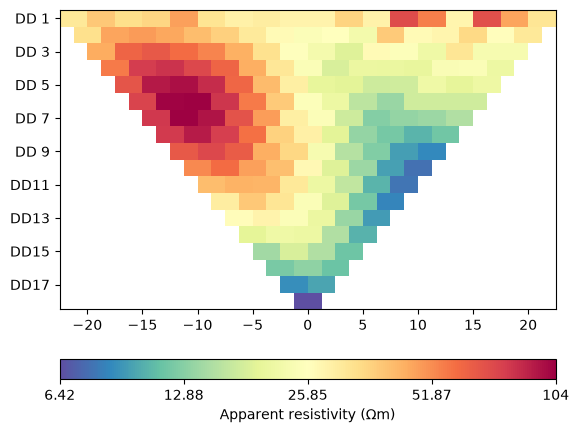

In [9]:
#produce pseudo-section
ert.show(synthetic_data)

In [10]:
#initiate ert Manager to invert the pseudo-section
mgr = ert.Manager('syn_data2.dat')
mgr.invert(verbose = True)

29/09/26 - 22:49:57 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 22:49:57 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/09/26 - 22:49:57 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 22:49:57 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/09/26 - 22:49:57 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/09/26 - 22:49:57 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/09/26 - 22:49:57 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 997 Cells: 1848 Boundaries: 1458
29/09/26 - 22:49:57 - pyGIMLi - INFO - Use median(data values)=28.2464216644856
29/09/26 - 22:49:57 - pyGIMLi - INFO - Created startmodel from forward operator:287, min/max=28.246422/28.246422
29/09/26 - 22:49:57 - pyGIMLi - INFO - Starting inversion.
29/09/26 - 22:49:57 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x735ba0988630>
29/09/26 - 22:49:57 - pyGIMLi - INFO - Data transf

Constructing Delaunay triangulation by divide-and-conquer method.
Delaunay milliseconds:  0
Recovering segments in Delaunay triangulation.
Segment milliseconds:  0
Removing unwanted triangles.
Spreading regional attributes and area constraints.
Hole milliseconds:  0
Adding Steiner points to enforce quality.
Quality milliseconds:  0

Writing vertices.
Writing triangles.
Writing segments.
Writing edges.

Output milliseconds:  0
Total running milliseconds:  0

Statistics:

  Input vertices: 49
  Input segments: 50
  Input holes: 0

  Mesh vertices: 268
  Mesh triangles: 462
  Mesh edges: 729
  Mesh exterior boundary edges: 72
  Mesh interior boundary edges: 15
  Mesh subsegments (constrained edges): 87

min/max(dweight) = 54.1357/99.9935
--------------------------------------------------------------------------------
Calculating response for model: min = 28.2464 max = 28.2464
Allocating memory for primary potential...... 0.000317704

No primary potential for secondary field calculation. C

29/09/26 - 22:49:58 - pyGIMLi - INFO - inv.iter 0 ... chi² = 3652.28


min/max(dweight) = 54.1357/99.9935
Building constraints matrix
constraint matrix of size(nBounds x nModel) 401 x 287
check Jacobian: wrong dimensions: (0x0) should be (171x287)  force: 1
jacobian size invalid, forced recalc: 1
Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.00202082:time: 0.201101s
sens sum: median = 1.04585 min = 0.955937 max = 1.25066
... 0.20293 s
min data = 6.41964 max data = 104.084 (171)
min error = 0.0100006 max error = 0.0184721 (171)
min response = 28.1625 max response = 28.2832 (171)
calc without reference model
0: rms/rrms(data, response) = 24.1397/82.2558%
0: chi^2(data, response, error, log) = 3652.28
0: Phi = 624540 + 0 * 20 = 624540
--------------------------------------------------------------------------------
inv.iter 1 ... solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 0.068281 max = 419.67
Using existing primary potentials.
Forward: time: 0.188313s
Response: min 

29/09/26 - 22:49:58 - pyGIMLi - INFO - chi² =  544.14 (dPhi = 84.74%) lam: 20.0


...

29/09/26 - 22:50:00 - pyGIMLi - INFO - chi² =    2.90 (dPhi = 9.43%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 5 ... 4: LS newModel: min = 0.569971; max = 518.247
4: LS newResponse: min = 6.70907; max = 102.902
4: rms/rrms(data, LS newResponse) = 0.767097/1.81239%
4: chi^2(data, LS newResponse, error, log) = 3.02874
4: Phi = 517.915+89.5897*20=2309.71
Performing line search with tau = 0.8
Calculating response for model: min = 0.545143 max = 522.303
Using existing primary potentials.
Forward: time: 0.208548s
Response: min = 6.87528 max = 102.973 mean = 34.8993
Reciprocity rms(modelReciprocity) 1.60102%, max: 3.58088%
4: Model: min = 0.545143; max = 522.303
4: Response: min = 6.75912; max = 103.145
4: rms/rrms(data, Response) = 0.732638/1.8028%
4: chi^2(data, Response, error, log) = 2.90008
4: Phi = 495.913+89.635*20=2288.61
Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.000298971:time: 0.141867s
sens sum: median = 1.58103 min = 0.95067 max = 3.467

29/09/26 - 22:50:00 - pyGIMLi - INFO - chi² =    2.81 (dPhi = 0.35%) lam: 20.0


 6.9225 max = 103.145 mean = 34.9627
Reciprocity rms(modelReciprocity) 1.59616%, max: 3.58699%
5: LS newModel: min = 0.517729; max = 527.002
5: LS newResponse: min = 6.80522; max = 103.319
5: rms/rrms(data, LS newResponse) = 0.693565/1.80335%
5: chi^2(data, LS newResponse, error, log) = 2.79546
5: Phi = 478.024+90.3028*20=2284.08
Performing line search with tau = 0.63
Calculating response for model: min = 0.527707 max = 525.259
Using existing primary potentials.
Forward: time: 0.207084s
Response: min = 6.90575 max = 103.082 mean = 34.939
Reciprocity rms(modelReciprocity) 1.59757%, max: 3.572%
5: Model: min = 0.527707; max = 525.259
5: Response: min = 6.7889; max = 103.255
5: rms/rrms(data, Response) = 0.70605/1.79508%
5: chi^2(data, Response, error, log) = 2.80826
5: Phi = 480.212+90.0194*20=2280.6
################################################################################
#                Abort criterion reached: dPhi = 0.35 (< 2.0%)                 #
############################

287 [35.814438858976644,...,2.3868038261938054]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x735ba09d9650>)

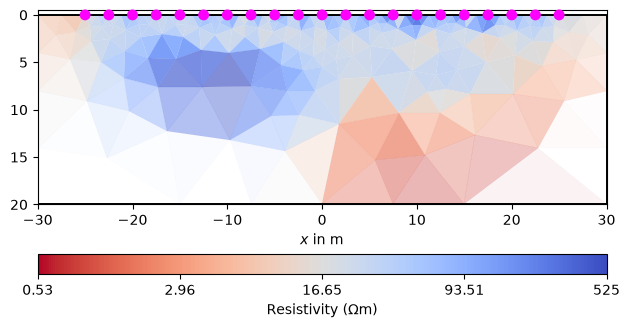

In [11]:
#visualize the inverted result

#import cmcrameri.cm as cmc
#mgr.showResult(logScale=True, cMap=cmc.vik)

mgr.showResult(cMap = 'coolwarm_r') #play with different colopr maps

#try scientific color mapping 
# to install, run
# pip install cmcrameri
## and import new colormaps
#import cmcrameri.cm as cmc
#mgr.showResult(logScale=True, cMap=cmc.vik)

(<Axes: xlabel='$x$ in m'>, None)

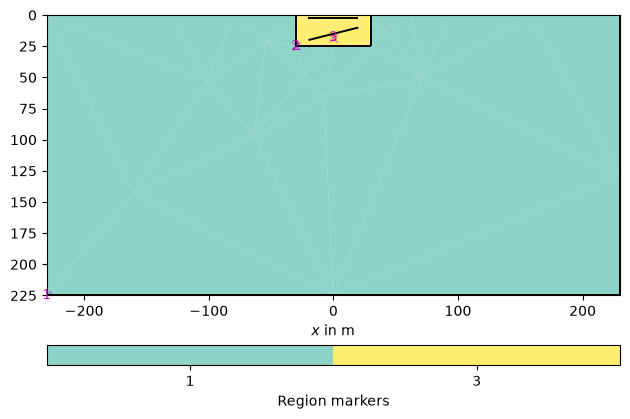

In [12]:
#improve the inverted data with geological knowledge

#create Piecewise Linear Complex (plc)
plc = mt.createParaMeshPLC(synthetic_data, paraDepth=25) 

#as we knew there are three different layers
# add those using two lines
line = mt.createLine(start = [-20, -20], end = [20, -10])
line2 = mt.createLine([-20,-2], [20, -2])
plc.addRegionMarker([0, -18], marker=3)
#make the plc geometry
plc += line
plc+= line2
pg.show(plc)

(<Axes: xlabel='$x$ in m'>, None)

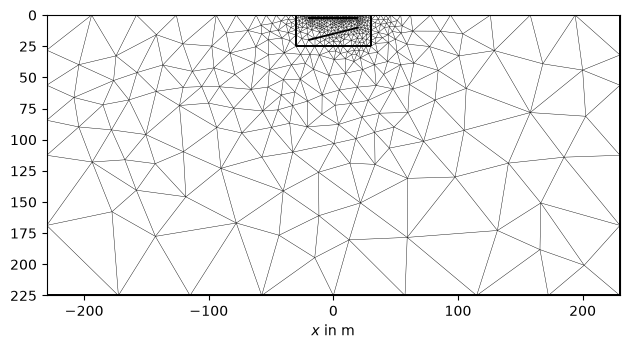

In [13]:
#create mesh for new plc
mesh = mt.createMesh(plc, quality = 34)
pg.show(mesh)

In [14]:
#incorporate the mesh within ert manager and invert
mgr.setMesh(mesh)
mgr.invert(verbose=True)

29/09/26 - 22:50:02 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 22:50:02 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/09/26 - 22:50:02 - pyGIMLi - INFO - Creating forward mesh from region infos.


Reset region parameter
RegionManager copying mesh ...0.00828671 s 
create NeighborInfos ... 2.4046e-05 s 
analyzing mesh ... 2 regions.
creating para domain ... 0.00359437 s
Found datafile: 21 electrodes
Found: 21 node-electrodes
Found non-Neumann domain
 updateDataDependency:: cleaning primpot
creating para domain ... 0.00509802 s


29/09/26 - 22:50:02 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/09/26 - 22:50:02 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2127 Cells: 4080 Boundaries: 3146
29/09/26 - 22:50:02 - pyGIMLi - INFO - Use median(data values)=28.2464216644856
29/09/26 - 22:50:02 - pyGIMLi - INFO - Created startmodel from forward operator:602, min/max=28.246422/28.246422
29/09/26 - 22:50:02 - pyGIMLi - INFO - Starting inversion.
29/09/26 - 22:50:02 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x735ba0988630>
29/09/26 - 22:50:02 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
29/09/26 - 22:50:02 - pyGIMLi - INFO - Model transformation: Logarithmic transform
29/09/26 - 22:50:02 - pyGIMLi - INFO - min/max (data): 6.42/104
29/09/26 - 22:50:02 - pyGIMLi - INFO - min/max (error): 1%/1.85%
29/09/26 - 22:50:02 - pyGIMLi - INFO - min/max (start model): 28.25/28.25


ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 node-electrodes
Found non-Neumann domain
0.0213332 s
FOP updating mesh dependencies ... 1.2321e-05 s
ModellingBase::setMesh() copying new mesh ... 0.0196977 s
FOP updating mesh dependencies ... 2.4266e-05 s
min/max(dweight) = 54.1357/99.9935
--------------------------------------------------------------------------------
Calculating response for model: min = 28.2464 max = 28.2464
Allocating memory for primary potential...... 0.000717784

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.521527s
Response: min = 28.1625 max = 28.2832 mean = 28.2274
Reciprocity rms(modelReciprocity) 0%, max: 0%


29/09/26 - 22:50:03 - pyGIMLi - INFO - inv.iter 0 ... chi² = 3652.28


...

29/09/26 - 22:50:09 - pyGIMLi - INFO - chi² =    2.25 (dPhi = 58.92%) lam: 20.0


S(8/6-std::mt): 0.000448617:time: 0.277897s
sens sum: median = 1.60937 min = 0.928871 max = 3.87056
... 0.279108 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 0.19739 max = 487.844
Using existing primary potentials.
Forward: time: 0.414607s
Response: min = 6.79475 max = 104.049 mean = 35.0824
Reciprocity rms(modelReciprocity) 0.641851%, max: 1.59894%
Performing line search with tau = 1
6: Model: min = 0.19739; max = 487.844
6: Response: min = 6.76626; max = 103.951
6: rms/rrms(data, Response) = 0.579283/1.63138%
6: chi^2(data, Response, error, log) = 2.24574
6: Phi = 384.022+65.6436*20=1696.89
--------------------------------------------------------------------------------
inv.iter 7 ... Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.000882002:time: 0.29809s
sens sum: median = 1.57993 min = 0.9211 max = 3.97111
... 0.29991 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: mi

29/09/26 - 22:50:10 - pyGIMLi - INFO - chi² =    2.22 (dPhi = 0.61%) lam: 20.0


7: Model: min = 0.217014; max = 486.283
7: Response: min = 6.77173; max = 103.857
7: rms/rrms(data, Response) = 0.585749/1.61889%
7: chi^2(data, Response, error, log) = 2.21866
7: Phi = 379.39+65.3537*20=1686.47
################################################################################
#                Abort criterion reached: dPhi = 0.61 (< 2.0%)                 #
################################################################################


602 [2.4651229939459,...,9.315745423039646]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x735ba0375d10>)

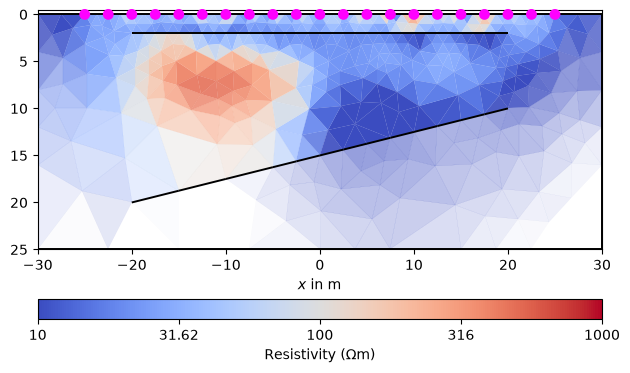

In [15]:
#visualize the final result
mgr.showResult(cMap = 'coolwarm', cMax = 1000, cMin = 10, logscale =True)